In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec


In [2]:
df = pd.read_csv('PhaseScan_data.csv').sample(frac = 1)
print(df.columns)

# feature : phase-separated or homogeneous
# Proteil_Dil : dilute phase G3BP1 concentraiton in uM
# Protein : total G3BP1 concentration in uM
# RNA: total RNA concentraiton in ng/ul
# Suramin: total suramin concentration in uM

Index(['feature', 'Protein_Dil', 'Protein', 'RNA', 'Suramin'], dtype='object')


In [3]:
# Function definition to extract phase boundary from data
# Based on phase separation probability

def phase_boundary(df, xcol, ycol, f_col,
                   bins=80, boundary_range=(0.4, 0.6),
                   smooth_sigma=1.0, cmap='coolwarm',
                   plot=True, contour=False,
                   slab_col=None, slab_val=None,     #surmain concentration slab
                   slab_thickness=None):
    

    # Filter slab if specified 
    if slab_col is not None and slab_val is not None and slab_thickness is not None:
        section = df[(df[slab_col] >= slab_val) &
                     (df[slab_col] < slab_val + slab_thickness)]
    else:
        section = df.copy()

    # Separate by phase classification 
    df_sep = section[section[f_col] == True]     # phase separated state
    df_dil = section[section[f_col] == False]    # homogeneous state

    # Compute histograms 
    H_sep, xedges, yedges = np.histogram2d(df_sep[xcol], df_sep[ycol], bins=bins)
    H_dil, _, _ = np.histogram2d(df_dil[xcol], df_dil[ycol], bins=[xedges, yedges])

    # Smooth histograms by Gaussian filter
    if smooth_sigma > 0:
        H_sep = gaussian_filter(H_sep, sigma=smooth_sigma, mode='reflect')
        H_dil = gaussian_filter(H_dil, sigma=smooth_sigma, mode='reflect')

    # Probability field
    H_total = H_sep + H_dil
    with np.errstate(invalid='ignore', divide='ignore'):
        P_sep = np.where(H_total > 0, H_sep / H_total, np.nan)

    # Grid coordinates (bin centers)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2
    Xc, Yc = np.meshgrid(xcenters, ycenters, indexing="ij")

    # Boundary extraction
    boundary_mask = (P_sep >= boundary_range[0]) & (P_sep <= boundary_range[1])
    boundary_points = np.vstack([Xc[boundary_mask], Yc[boundary_mask]]).T


    # Plot if called
    if plot:
        plt.figure(figsize=(6, 5))
        plt.pcolormesh(xedges, yedges, P_sep.T, cmap=cmap, shading='auto')
        plt.scatter(boundary_points[:, 0], boundary_points[:, 1],
                    color='k', s=8, label=f'Boundary {boundary_range}')
        plt.colorbar(label='$P_{sep}$')
        plt.xlabel(xcol)
        plt.ylabel(ycol)

        title = f"Phase Boundary on {xcol}–{ycol} plane"
        if slab_col is not None:
            title += f"\n{slab_col} = {slab_val}–{slab_val + slab_thickness}"
        plt.title(title)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    # Return results
    return {"boundary_points": boundary_points,
            "Xc": Xc, "Yc": Yc,
            "P_sep": P_sep,
            "xedges": xedges, "yedges": yedges,
            "section": section
           }


In [4]:
# Definition of functions for global fitting


# ---------------------
# Phase Boundary Model
# ---------------------
def model(x, s, b, c, p):
    return s * x**(-b) * np.exp(c * x * np.exp(-p * x))

# This is the functional form derived in paper, though with different parameter naming here


# ------------------------
# Global model components
# ------------------------

# Hill function
def theta_hill(S, K_S, n):
    S = np.asarray(S, dtype=float)
    return 1.0 / (1.0 + (S / K_S)**n)

#
def model_base(x, s, b, c, p):
    return s * x**(-b) * np.exp(c * x * np.exp(-p * x))


# Global fitting function
# Implemented with c/c_0 = θ^2, and p/p_0 = θ

def model_global(X, K_S, n, c0, p0, *slab_params):
    x = np.asarray(X[0], dtype=float)
    slab_idx = np.asarray(X[1], dtype=int)

    nslabs = len(slab_params) // 2
    s_arr = np.array(slab_params[0::2], dtype=float)
    b_arr = np.array(slab_params[1::2], dtype=float)

    S_point = slab_values[slab_idx].astype(float)

    th = theta_hill(S_point, K_S, n)
    c = c0 * th**2
    p = p0 * th

    s = s_arr[slab_idx]
    b = b_arr[slab_idx]

    return model_base(x, s, b, c, p)


def get_fit_and_envelope(i, xx, popt, perr, model_global, lower=None, upper=None):
    X_plot = np.vstack([xx, np.full_like(xx, i, dtype=float)])
    y_fit = model_global(X_plot, *popt)

    y_iter = []
    base = np.array(popt, dtype=float)
    sig  = np.array(perr, dtype=float)

    # assumes parameter order:
    # [global0, global1, global2, global3, s0, b0, s1, b1, ...]
    idx_s = 4 + 2*i
    idx_b = 4 + 2*i + 1

    for dKS in (-0.1, +0.1):
        for dn in (-0.1, +0.1):
            for dc0 in (-0.1, +0.1):
                for dp0 in (-0.1, +0.1):
                    for ds in (-0.1, +0.1):
                        for db in (-0.1, +0.1):
                            params = base.copy()
                            params[0] += dKS * sig[0]
                            params[1] += dn  * sig[1]
                            params[2] += dc0 * sig[2]
                            params[3] += dp0 * sig[3]
                            params[idx_s] += ds * sig[idx_s]
                            params[idx_b] += db * sig[idx_b]

                            if lower is not None:
                                params = np.maximum(params, np.array(lower))
                            if upper is not None:
                                params = np.minimum(params, np.array(upper))

                            y_iter.append(model_global(X_plot, *params))

    y_hi = np.max(y_iter, axis=0)
    y_lo = np.min(y_iter, axis=0)
    return X_plot, y_fit, y_lo, y_hi

In [5]:
# Global Fitting: Panel (a)

# -----------
# Slab setup
# -----------
slab_col = "Suramin"
slab_values = np.array([0, 1, 2, 3, 4, 5, 6, 7], dtype=float)
slab_thickness = 1.0
nslabs = len(slab_values)

# ----------------------------------
# Extract boundaries + COUNT DATA
# ----------------------------------
COORS = []
SECTIONS = []

ndata_total = np.zeros(nslabs, dtype=int)
ndata_dil   = np.zeros(nslabs, dtype=int)
ndata_den   = np.zeros(nslabs, dtype=int)

bcount_raw  = np.zeros(nslabs, dtype=int)
bcount_fit  = np.zeros(nslabs, dtype=int)


lower = [1e-6, 0.1, -10, -10] + [-10, -10]*nslabs
upper = [1e3, 10, 10, 10] + [10, 10]*nslabs



for i, slab_val in enumerate(slab_values):

    # Phase boundary points extracted for each suramin slab
    result = phase_boundary( df=df, xcol='RNA', ycol='Protein', f_col='feature',
                             slab_col=slab_col, slab_val=slab_val, slab_thickness=slab_thickness,
                             bins=60, boundary_range=(0.4, 0.6),
                             smooth_sigma=1.0,
                             plot=False, contour=False )

    # ---- boundary extraction ----
    boundary = result["boundary_points"]
    x_data, y_data = boundary[:, 0], boundary[:, 1]
    
    
    # Select less noisy region for fitting
    # Can manually delete outliers boundary points misidentified previously
    mask = (x_data > 1e-5) & np.isfinite(x_data) & np.isfinite(y_data)
    exclude_region = (x_data > 50) & (y_data > 3)
    mask = mask & (~exclude_region)
    x_m = x_data[mask]
    y_m = y_data[mask]

    bcount_raw[i] = len(x_m)

    COORS.append([x_m, y_m])
    
    # Count total data points in each suramin slab

    section = result["section"]
    SECTIONS.append(section)

    label = section['feature'].values.astype(int)
    ndata_dil[i] = np.sum(label == 0)
    ndata_den[i] = np.sum(label == 1)
    ndata_total[i] = ndata_dil[i] + ndata_den[i]
    
    
    
# --------------------------------------------------
# Build ONE concatenated dataset for global fitting
# --------------------------------------------------
x_all, y_all, slab_idx_all = [], [], []

for i, (x_i, y_i) in enumerate(COORS):

    m = (y_i < 6)
    x_i = x_i[m]
    y_i = y_i[m]

    bcount_fit[i] = len(x_i)

    if len(x_i) == 0:
        continue

    x_all.append(x_i)
    y_all.append(y_i)
    slab_idx_all.append(np.full_like(x_i, i, dtype=int))

x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)
slab_idx_all = np.concatenate(slab_idx_all)

X_all = np.vstack([x_all, slab_idx_all.astype(float)])
    

# --------------------------------------------------------------
# print data number counts
# --------------------------------------------------------------
print("\n=== Data Number Counts Per Suramin Slab ===")
for i in range(nslabs):
    print(
        f"[suramin] = {slab_values[i]:.0f} µM : "
        f"N={ndata_total[i]} (dil={ndata_dil[i]}, den={ndata_den[i]}), "
        f"B={bcount_fit[i]}/{bcount_raw[i]}"
    )


# --------------------------------------------------------------
# Global fit
# --------------------------------------------------------------
popt, pcov, infodict, errmsg, ier = curve_fit(
    model_global, X_all, y_all,
    p0=[2.0, 1.0, 0.1, 0.001] + [10.0, 1.0] * nslabs,       # initial guess: [K_S, n, c0, p0] + [*slab_params]
    bounds=(                                                # Set parameter bounds
        [1e-12, 1e-8, 0.0, 0.0] + [1e-12, 0.0] * nslabs,
        [np.inf, np.inf, np.inf, np.inf] + [np.inf, np.inf] * nslabs
    ),
    maxfev=200000, full_output=True
)

# Covariant error
perr = np.sqrt(np.diag(pcov))

print("Convergence flag (ier):", ier)                                    # Convergence flag: ier ∈ {1, 2, 3, 4}
print("Message:", errmsg)                                                # Convergence confirmed
print("Number of function evaluations (nfev):", infodict["nfev"])        # Print number of iteration



# Store parameter s and b fitted 
s_fit = np.array([popt[4+2*i]     for i in range(nslabs)], dtype=float)
b_fit = np.array([popt[4+2*i + 1] for i in range(nslabs)], dtype=float)
s_err = np.array([perr[4+2*i]     for i in range(nslabs)], dtype=float)
b_err = np.array([perr[4+2*i + 1] for i in range(nslabs)], dtype=float)


# Fitted parameter s and b printed
print("\n=== Per-slab parameters ===")
for i in range(nslabs):
    print(f"[suramin] = {slab_values[i]:.0f} µM:  s = {s_fit[i]:.6g} ± {s_err[i]:.3g},  b = {b_fit[i]:.6g} ± {b_err[i]:.3g}")


    
    
# Fitted Hill parameters
print("\n=== Hill parameters ===")
print(f"suramin-binding K_s = {popt[0]:.4g} ± {perr[0]:.4g}, Hill coefficient n = {popt[1]:.4g} ± {perr[1]:.4g}")
print(f"c_0 = {popt[2]:.4g} ± {perr[2]:.4g},  p_0 = {popt[3]:.4g} ± {perr[3]:.4g}")






=== Data Number Counts Per Suramin Slab ===
[suramin] = 0 µM : N=24449 (dil=6181, den=18268), B=76/87
[suramin] = 1 µM : N=16247 (dil=4200, den=12047), B=52/66
[suramin] = 2 µM : N=17947 (dil=3688, den=14259), B=52/73
[suramin] = 3 µM : N=17020 (dil=4284, den=12736), B=92/110
[suramin] = 4 µM : N=15834 (dil=5953, den=9881), B=93/102
[suramin] = 5 µM : N=15905 (dil=6636, den=9269), B=107/120
[suramin] = 6 µM : N=14244 (dil=7721, den=6523), B=156/166
[suramin] = 7 µM : N=12410 (dil=7787, den=4623), B=159/167
Convergence flag (ier): 2
Message: `ftol` termination condition is satisfied.
Number of function evaluations (nfev): 36

=== Per-slab parameters ===
[suramin] = 0 µM:  s = 4.54871 ± 0.999,  b = 0.920865 ± 0.214
[suramin] = 1 µM:  s = 5.31822 ± 0.743,  b = 0.849685 ± 0.106
[suramin] = 2 µM:  s = 3.54006 ± 0.382,  b = 0.651088 ± 0.0758
[suramin] = 3 µM:  s = 1.34632 ± 0.14,  b = 0.331645 ± 0.0291
[suramin] = 4 µM:  s = 5.32841 ± 0.316,  b = 0.528748 ± 0.0417
[suramin] = 5 µM:  s = 4.1

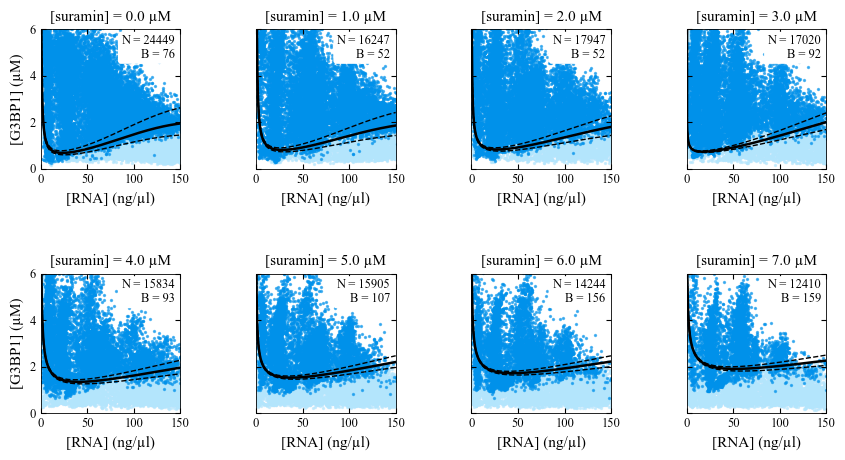

In [6]:
# --------------------------------------------------------------
# Plot
# --------------------------------------------------------------
n = nslabs
ncols = int(np.ceil(n / 2))
nrows = 2


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.0,
})



panel_size = 2.4 
fig = plt.figure(figsize=(panel_size * ncols, panel_size * nrows))
axes = fig.subplots(nrows, ncols, sharey=True).flatten()

for ax in axes:
    ax.set_box_aspect(1)   # ensures square axes

xx = np.linspace(1e-5, 150, 500)

names = [f"{val} µM" for val in slab_values]
    

for i, ax in enumerate(axes[:nslabs]):

    section = SECTIONS[i]
    label = section['feature'].values.astype(int)

    dil = section[label == 0]
    den = section[label == 1]

   
    ax.scatter(dil['RNA'], dil['Protein'], s=2, color='#b3e5fc', alpha=0.6)
    ax.scatter(den['RNA'], den['Protein'], s=2, color='#0091ea', alpha=0.6)


    X_plot, y_fit, yb_lo, yb_hi = get_fit_and_envelope(
    i, xx, popt, perr, model_global, lower=lower, upper=upper)

    ax.plot(xx, y_fit, color="black", lw=1.8)
    ax.plot(xx, yb_hi, color="black", ls="--", lw=1.0)
    ax.plot(xx, yb_lo, color="black", ls="--", lw=1.0)

    # Data number counts printed in each panel
    txt = (  f"N = {ndata_total[i]}\n"  f"B = {bcount_fit[i]}" )

    ax.text(
        0.96, 0.96, txt,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=1.0),
        zorder=10
    )

    ax.set_xlabel("[RNA] (ng/µl)")
    ax.set_title("[suramin] = " + names[i])
    ax.set_xlim(0, 150)

axes[0].set_ylabel("[G3BP1] (µM)")
axes[4].set_ylabel("[G3BP1] (µM)")

for ax in axes[nslabs:]:
    ax.remove()

plt.ylim(0, 6)

plt.subplots_adjust(
    left=0.12,
    right=0.98,
    bottom=0.10,
    top=0.90,
    wspace=0.20,   # horizontal spacing
    hspace=0.75    # vertical spacing
)

plt.show()

In [7]:
# Calculate physical parameters: 
# Three-body repulsion χ_3, Competition Δχ, G3BP1-RNA dissociation constant K_D


# Global Hill parameters
Ks_fit, n_fit, c0_fit, p0_fit = popt[:4]
Cglob = pcov[:4, :4]  # covariance of [Ks, n, c0, p0]

slab_values = np.array([0,1,2,3,4,5,6,7], dtype=float)


# Derivatives used to calculate error in r = p/c
def dtheta_dKs(S, Ks, n):
    # θ = 1/(1+u), u=(S/Ks)^n
    # dθ/dKs = θ^2 * u * n/Ks
    S = np.asarray(S, dtype=float)
    th = theta_hill(S, Ks, n)
    u = (S / Ks)**n
    return th**2 * u * (n / Ks)

def dtheta_dn(S, Ks, n):
    # dθ/dn = -θ^2 * u * ln(S/Ks)
    S = np.asarray(S, dtype=float)
    th = theta_hill(S, Ks, n)
    u = (S / Ks)**n
    # handle S=0 safely: u=0 and ln is irrelevant; set ln(0) to 0
    with np.errstate(divide='ignore', invalid='ignore'):
        ln = np.log(S / Ks)
    ln = np.where(np.isfinite(ln), ln, 0.0)
    return -th**2 * u * ln


# function to calculate Hill constrained parameter c and p
def c_of_S(S, Ks, n, c0):
    th = theta_hill(S, Ks, n)
    return c0 * th**2

def p_of_S(S, Ks, n, p0):
    th = theta_hill(S, Ks, n)
    return p0 * th


# Compute c(S), p(S) and their errors
c_vals = c_of_S(slab_values, Ks_fit, n_fit, c0_fit)
p_vals = p_of_S(slab_values, Ks_fit, n_fit, p0_fit)
c_err = np.zeros_like(c_vals)
p_err = np.zeros_like(p_vals)
cov_cp = np.zeros((len(slab_values), 2, 2))  # per-slab covariance of (c,p)


for i, S in enumerate(slab_values):
    th = theta_hill(S, Ks_fit, n_fit)
    dth_Ks = dtheta_dKs(S, Ks_fit, n_fit)
    dth_n  = dtheta_dn(S, Ks_fit, n_fit)

    # Gradients wrt [Ks, n, c0, p0]
    # c = c0 * th^2
    dc_dKs = c0_fit * 2*th * dth_Ks
    dc_dn  = c0_fit * 2*th * dth_n
    dc_dc0 = th**2
    dc_dp0 = 0.0

    # p = p0 * th
    dp_dKs = p0_fit * dth_Ks
    dp_dn  = p0_fit * dth_n
    dp_dc0 = 0.0
    dp_dp0 = th

    J = np.array([
        [dc_dKs, dc_dn, dc_dc0, dc_dp0],
        [dp_dKs, dp_dn, dp_dc0, dp_dp0],
    ])  # shape (2,4)

    Cov = J @ Cglob @ J.T  # (2,2)
    cov_cp[i] = Cov
    c_err[i] = np.sqrt(max(Cov[0,0], 0.0))
    p_err[i] = np.sqrt(max(Cov[1,1], 0.0))

# --------------------------------------------
# Ratio r = p/c with propagated uncertainty
# --------------------------------------------
ratio_vals = p_vals / c_vals
ratio_err = np.zeros_like(ratio_vals)
for i in range(len(slab_values)):
    c = c_vals[i]
    p = p_vals[i]
    Cov = cov_cp[i]  # covariance of [c,p]

    # dr/dc = -p/c^2, dr/dp = 1/c
    grad = np.array([-p/(c**2), 1.0/c])  # shape (2,)
    var_r = grad @ Cov @ grad
    ratio_err[i] = np.sqrt(max(var_r, 0.0))



# Physical Quantities evaluated
# L^1 = 10**3, L^2 = 10**4, 1ng/ul = 0.48 * 10**(-3) uM

# Three-body repulsion
repulsion_vals = c_vals/(1.8*1000*0.48*1e-9)
repulsion_err  = c_err /(1.8*1000*0.48*1e-9)

# Competition
competition_vals = p_vals/(1.8*0.01*0.48*0.1)
competition_err  = p_err /(1.8*0.01*0.48*0.1)

# G3BP1-RNA dissociation constant
kd_vals = ratio_vals * ((2*100)/(1.8))
kd_err  = ratio_err  * ((2*100)/(1.8))


# Print per suramin slab
print("\n--- Inferred Physical Quantities ---\n")

for S, v_1, v_2, v_3, e_1, e_2, e_3 in zip(slab_values, 
                                           repulsion_vals, repulsion_err, 
                                           competition_vals, competition_err,
                                           kd_vals, kd_err):
    print(f"[suramin]={S:g}µM: χ_3 = {v_1:.2f} ± {e_1:.2f}, Δχ = {v_2:.3f} ± {e_2:.3f}, K_D = {v_3:.3f} ± {e_3:.3f} μM")
    print()



--- Inferred Physical Quantities ---

[suramin]=0µM: χ_3 = 55734.90 ± 0.82, Δχ = 18511.023 ± 10.003, K_D = 5.018 ± 1.911 μM

[suramin]=1µM: χ_3 = 44203.31 ± 0.54, Δχ = 8679.599 ± 11.232, K_D = 4.469 ± 1.264 μM

[suramin]=2µM: χ_3 = 32952.48 ± 0.49, Δχ = 5900.876 ± 13.009, K_D = 3.858 ± 1.172 μM

[suramin]=3µM: χ_3 = 24539.12 ± 0.42, Δχ = 4136.405 ± 15.075, K_D = 3.329 ± 1.193 μM

[suramin]=4µM: χ_3 = 18516.15 ± 0.34, Δχ = 2630.570 ± 17.355, K_D = 2.892 ± 1.155 μM

[suramin]=5µM: χ_3 = 14214.56 ± 0.27, Δχ = 1618.735 ± 19.807, K_D = 2.534 ± 1.175 μM

[suramin]=6µM: χ_3 = 11107.18 ± 0.22, Δχ = 1219.082 ± 22.407, K_D = 2.240 ± 1.511 μM

[suramin]=7µM: χ_3 = 8826.06 ± 0.20, Δχ = 1256.189 ± 25.137, K_D = 1.997 ± 2.255 μM



In [8]:
# --------------------------------------------------------------
# Normalize to first point [suramin] = 0 µM
# Returns:
#   Qn      = Q/Q0
#   Qn_err_meas = propagated error using ONLY per-point measurement error
#                (does NOT include the global reference uncertainty term)
#   rel0    = e0/Q0 (global normalization fractional uncertainty)
# --------------------------------------------------------------
def normalize_to_first_separate_norm(vals, errs):
    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)

    Q0, e0 = float(vals[0]), float(errs[0])
    if (not np.isfinite(Q0)) or (Q0 == 0.0) or (not np.isfinite(e0)):
        raise ValueError("Bad reference Q0/e0 for normalization.")

    Qn = vals / Q0

    # measurement-only propagation: σ(Q/Q0) ≈ σ(Q)/Q0 (treat Q0 as exact here)
    Qn_err_meas = errs / abs(Q0)

    # make the reference point error the measurement-only one (no √2)
    Qn_err_meas[0] = e0 / abs(Q0)

    rel0 = abs(e0 / Q0)  # global fractional uncertainty for normalization
    return Qn, Qn_err_meas, rel0


# Three-body repulsion normalized
chi3n, chi3n_err, rel0_chi3 = normalize_to_first_separate_norm(repulsion_vals,  repulsion_err)

# Competition normalized
dchin, dchin_err, rel0_dchi = normalize_to_first_separate_norm(competition_vals, competition_err)

# K_D normalized
kdn, kdn_err, rel0_kd = normalize_to_first_separate_norm(kd_vals, kd_err)


# Print normalized results
print("\n--- Normalized to [suramin] = 0 µM ---\n")

for S, v_1, v_2, v_3, e_1, e_2, e_3 in zip(slab_values, chi3n, chi3n_err,
                                           dchin, dchin_err, kdn, kdn_err):
    print(
    f"[Suramin]={S:g} µM: χ_3^0 = {v_1:.3f}±{e_1:.3f}, "
    f"Δχ^0 = {v_2:.3f}±{e_2:.3f}, K_D^0 = {v_3:.3f}±{e_3:.3f} µM"
    )
    print()




--- Normalized to [suramin] = 0 µM ---

[Suramin]=0 µM: χ_3^0 = 1.000±0.164, Δχ^0 = 0.332±1.000, K_D^0 = 1.000±0.191 µM

[Suramin]=1 µM: χ_3^0 = 0.793±0.109, Δχ^0 = 0.156±1.123, K_D^0 = 0.891±0.126 µM

[Suramin]=2 µM: χ_3^0 = 0.591±0.098, Δχ^0 = 0.106±1.301, K_D^0 = 0.769±0.117 µM

[Suramin]=3 µM: χ_3^0 = 0.440±0.084, Δχ^0 = 0.074±1.507, K_D^0 = 0.664±0.119 µM

[Suramin]=4 µM: χ_3^0 = 0.332±0.068, Δχ^0 = 0.047±1.735, K_D^0 = 0.576±0.116 µM

[Suramin]=5 µM: χ_3^0 = 0.255±0.053, Δχ^0 = 0.029±1.980, K_D^0 = 0.505±0.117 µM

[Suramin]=6 µM: χ_3^0 = 0.199±0.044, Δχ^0 = 0.022±2.240, K_D^0 = 0.446±0.151 µM

[Suramin]=7 µM: χ_3^0 = 0.158±0.040, Δχ^0 = 0.023±2.513, K_D^0 = 0.398±0.225 µM



In [9]:
# --------------------------------------------------------------
# Data
# --------------------------------------------------------------
suramin = np.asarray(slab_values, dtype=float)  
slab_values = np.asarray(slab_values, dtype=float)

Ks_fit, n_fit = float(popt[0]), float(popt[1])
C_Kn = pcov[np.ix_([0, 1], [0, 1])]  # cov(Ks, n)


# --------------------------------------------------------------
# Covariant envelope via sampling (Ks,n) + optional global scale g
# --------------------------------------------------------------
def hill_envelope_with_norm(
    x, Ks_mean, n_mean, cov_Kn,
    transform="theta", rel_norm0=0.0,
    nsamp=4000, pct=(16, 84), seed=0
):
    x = np.asarray(x, float)
    rng = np.random.default_rng(seed)

    samp = rng.multivariate_normal(mean=[Ks_mean, n_mean], cov=cov_Kn, size=nsamp)
    Ks_s = np.clip(samp[:, 0], 1e-15, np.inf)
    n_s  = np.clip(samp[:, 1], 1e-12, np.inf)

    # global multiplicative normalization per draw
    if rel_norm0 > 0:
        g = rng.normal(loc=1.0, scale=rel_norm0, size=Ks_s.size)
        g = np.clip(g, 0.0, np.inf)  # keep physical positive scale
    else:
        g = np.ones_like(Ks_s)

    th = 1.0 / (1.0 + (x[None, :] / Ks_s[:, None])**n_s[:, None])

    if transform == "theta":
        y = th
    elif transform == "theta2":
        y = th**2
    elif transform == "invtheta":
        y = 1.0 / th
    else:
        raise ValueError("Unknown transform")

    ys = g[:, None] * y

    y_med = np.nanpercentile(ys, 50, axis=0)
    y_lo  = np.nanpercentile(ys, pct[0], axis=0)
    y_hi  = np.nanpercentile(ys, pct[1], axis=0)
    return y_med, y_lo, y_hi


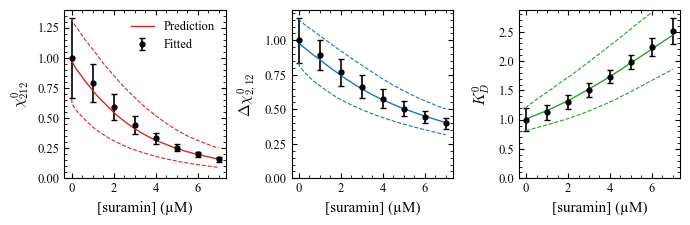

Used Hill parameters: K_s = 5.078 ± 1.492, n = 1.29 ± 0.4648


In [10]:
# Plot Hill constrained physical parameter trends

# Smooth grid
x_fit = np.linspace(0.0, float(np.max(slab_values)), 400)

# Envelopes (16–84% ≈ 1σ for near-Gaussian)
theta_med,  theta_lo,  theta_hi  = hill_envelope_with_norm(
    x_fit, Ks_fit, n_fit, C_Kn, transform="theta",  rel_norm0=rel0_dchi, nsamp=4000, seed=1
)
theta2_med, theta2_lo, theta2_hi = hill_envelope_with_norm(
    x_fit, Ks_fit, n_fit, C_Kn, transform="theta2", rel_norm0=rel0_chi3, nsamp=4000, seed=2
)
inv_med, inv_lo, inv_hi = hill_envelope_with_norm(
    x_fit, Ks_fit, n_fit, C_Kn, transform="invtheta", rel_norm0=rel0_kd, nsamp=4000, seed=3
)



# --------------------------------------------------------------
# Plot 3 panels: normalized physical quantities + Hill shape
# --------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})
fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.15))

# (a) χ3 ~ θ^2
ax = axes[0]
ax.errorbar(slab_values, chi3n, yerr=chi3n_err, fmt='o', color='k', ms=3.5, label="Fitted")
ax.plot(x_fit, theta2_med, '-', color='tab:red', lw=1.0, label="Prediction")
ax.plot(x_fit, theta2_lo,  '--', color='tab:red', lw=0.8)
ax.plot(x_fit, theta2_hi,  '--', color='tab:red', lw=0.8)
ax.set_xlabel("[suramin] (µM)")
ax.set_ylabel(r"$\chi^{0}_{212} $")
ax.set_ylim(0, max(1.05, 1.05*np.nanmax(chi3n + chi3n_err)))
ax.minorticks_on()
ax.tick_params(which='both', direction='in')

# (b) Δχ ~ θ
ax = axes[1]
ax.errorbar(slab_values, dchin, yerr=dchin_err, fmt='o', color='k', ms=3.5, label="Fitted")
ax.plot(x_fit, theta_med, '-', color='tab:blue', lw=1.0, label="Prediction")
ax.plot(x_fit, theta_lo,  '--', color='tab:blue', lw=0.8)
ax.plot(x_fit, theta_hi,  '--', color='tab:blue', lw=0.8)
ax.set_xlabel("[suramin] (µM)")
ax.set_ylabel(r"$\Delta\chi^{0}_{2,12} $")
ax.set_ylim(0, max(1.05, 1.05*np.nanmax(dchin + dchin_err)))
ax.minorticks_on()
ax.tick_params(which='both', direction='in')

# (c) KD ~ 1/θ
ax = axes[2]
ax.errorbar(slab_values, kdn, yerr=kdn_err, fmt='o', color='k', ms=3.5, label="Fitted")
ax.plot(x_fit, inv_med, '-', color='tab:green', lw=1.0, label="Prediction")
ax.plot(x_fit, inv_lo,  '--', color='tab:green', lw=0.8)
ax.plot(x_fit, inv_hi,  '--', color='tab:green', lw=0.8)
ax.set_xlabel("[suramin] (µM)")
ax.set_ylabel(r"$K_D^0$")
ax.set_ylim(0, max(1.05, 1.05*np.nanmax(kdn + kdn_err)))
ax.minorticks_on()
ax.tick_params(which='both', direction='in')

# Optional: one shared legend
axes[0].legend(loc="upper right", handlelength=1.8, fontsize=9)

plt.tight_layout(pad=0.35, w_pad=0.7)
plt.show()

print(f"Used Hill parameters: K_s = {popt[0]:.4g} ± {perr[0]:.4g}, n = {popt[1]:.4g} ± {perr[1]:.4g}")


In [11]:
# Perform Hill transformation for linear visualization


# --------------------------------------------------------------
# Choose whether to add global normalization into the point errors.
# Set False if chi3n_err etc already include denom uncertainty.
# --------------------------------------------------------------
INCLUDE_NORM_IN_ERR = True

if INCLUDE_NORM_IN_ERR:
    chi3n_err_use = np.sqrt(chi3n_err**2 + (rel0_chi3 * chi3n)**2)
    dchin_err_use = np.sqrt(dchin_err**2 + (rel0_dchi * dchin)**2)
    kdn_err_use   = np.sqrt(kdn_err**2   + (rel0_kd   * kdn)**2)
else:
    chi3n_err_use = np.asarray(chi3n_err, float)
    dchin_err_use = np.asarray(dchin_err, float)
    kdn_err_use   = np.asarray(kdn_err, float)

# --------------------------------------------------------------
# Hill-linear variables: X = ln S (exclude S=0)
# --------------------------------------------------------------
eps = 1e-12
maskS = suramin > 0
S = suramin[maskS]
X = np.log(S)


# (a) from chi3n = θ^2  ->  g = 1/θ - 1 = 1/sqrt(chi3n) - 1
chi0     = np.asarray(chi3n[maskS], float)
chi0_err = np.asarray(chi3n_err_use[maskS], float)

chi0 = np.clip(chi0, eps, np.inf)
g_chi = 1.0 / np.sqrt(chi0) - 1.0

good_chi = np.isfinite(X) & np.isfinite(g_chi) & np.isfinite(chi0_err) & (g_chi > 0)
x_chi_lin  = X[good_chi]
y_chi3_lin   = np.log(g_chi[good_chi])

# dy/dv for y = ln(1/sqrt(v) - 1)
# g(v)=v^{-1/2}-1; dg/dv = -1/(2 v^{3/2}); dy/dv = (dg/dv)/g
dg_dv = -0.5 * chi0**(-1.5)
dy_dv = dg_dv / g_chi
y_chi3_err_lin   = np.abs(dy_dv[good_chi]) * chi0_err[good_chi]




# (b) from dchin = θ  ->  g = 1/θ - 1 = 1/dchin - 1
dchi0     = np.asarray(dchin[maskS], float)
dchi0_err = np.asarray(dchin_err_use[maskS], float)

dchi0 = np.clip(dchi0, eps, np.inf)
g_dchi = 1.0 / dchi0 - 1.0

good_dchi = np.isfinite(X) & np.isfinite(g_dchi) & np.isfinite(dchi0_err) & (g_dchi > 0)
x_dchi_lin  = X[good_dchi]
y_dchi_lin   = np.log(g_dchi[good_dchi])

# y = ln(1/θ - 1); dy/dθ = -1/[θ(1-θ)] is ONLY for θ in (0,1).
# Here we use g=1/θ-1, dy/dθ = (d/dθ ln g)= (1/g)*(-1/θ^2)
dy_dtheta = (-1.0 / (dchi0**2)) / g_dchi
y_dchi_err_lin   = np.abs(dy_dtheta[good_dchi]) * dchi0_err[good_dchi]



# (c) from kdn = 1/θ -> g = 1/θ - 1 = kdn - 1
kd0     = np.asarray(kdn[maskS], float)
kd0_err = np.asarray(kdn_err_use[maskS], float)

g_kd = kd0 - 1.0
good_kd = np.isfinite(X) & np.isfinite(g_kd) & np.isfinite(kd0_err) & (g_kd > 0)
x_kd_lin  = X[good_kd]
y_kd_lin   = np.log(g_kd[good_kd])

# y = ln(kd0 - 1); dy/dkd0 = 1/(kd0-1)
y_kd_err_lin   = np.abs(1.0 / g_kd[good_kd]) * kd0_err[good_kd]




# --------------------------------------------------------------
# Straight-line Hill transformation + envelope: 
# ln ((y_0/y)^(1/\alpha)) = n ln S - n ln Ks
# --------------------------------------------------------------
x_fit = np.linspace(np.min(X), np.max(X), 400)

def hill_logline(x, Ks, n):
    Ks = max(float(Ks), 1e-15)
    n  = max(float(n), 1e-12)
    return n * np.log(Ks) - n * x

def hill_logline_envelope(x, Ks_mean, n_mean, cov_Kn, nsamp=4000, pct=(16,84), seed=1):
    rng = np.random.default_rng(seed)
    samp = rng.multivariate_normal([Ks_mean, n_mean], cov_Kn, size=nsamp)
    Ks_s = np.clip(samp[:, 0], 1e-15, np.inf)
    n_s  = np.clip(samp[:, 1], 1e-12, np.inf)

    Ys = (n_s[:, None] * x[None, :]) - (n_s[:, None] * np.log(Ks_s)[:, None])
    y_med_lin = np.percentile(Ys, 50, axis=0)
    y_lo_lin  = np.percentile(Ys, pct[0], axis=0)
    y_hi_lin  = np.percentile(Ys, pct[1], axis=0)
    return y_med_lin, y_lo_lin, y_hi_lin

yfit_lin, ylo_lin, yhi_lin = hill_logline_envelope(x_fit, Ks_fit, n_fit, C_Kn, nsamp=3000, seed=7)




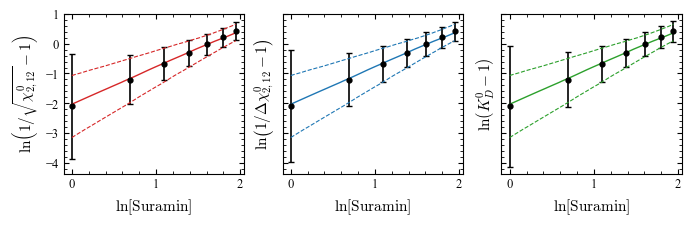

In [12]:
# --------------------------------------------------------------
# Plot linear Hill transformed physical parameters visualization
# --------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.15), sharey=True)

# χ^0_{2,12}
axes[0].errorbar(x_chi_lin, y_chi3_lin, yerr=y_chi3_err_lin, fmt='o', color='k', ms=3.5)
axes[0].plot(x_fit, yfit_lin, '-',  color='tab:red',   lw=1.0)
axes[0].plot(x_fit, ylo_lin,  '--', color='tab:red',   lw=0.8)
axes[0].plot(x_fit, yhi_lin,  '--', color='tab:red',   lw=0.8)
axes[0].set_xlabel(r"$\ln[\mathrm{Suramin}]$")
axes[0].set_ylabel(r"$\ln\!\left(1/\sqrt{\chi^{0}_{2,12}}-1\right)$")
axes[0].minorticks_on()
axes[0].tick_params(which='both', direction='in')

# Δχ^0_{2,12}
axes[1].errorbar(x_dchi_lin, y_dchi_lin, yerr=y_dchi_err_lin, fmt='o', color='k', ms=3.5)
axes[1].plot(x_fit, yfit_lin, '-',  color='tab:blue',  lw=1.0)
axes[1].plot(x_fit, ylo_lin,  '--', color='tab:blue',  lw=0.8)
axes[1].plot(x_fit, yhi_lin,  '--', color='tab:blue',  lw=0.8)
axes[1].set_xlabel(r"$\ln[\mathrm{Suramin}]$")
axes[1].set_ylabel(r"$\ln\!\left(1/\Delta\chi^{0}_{2,12}-1\right)$")
axes[1].minorticks_on()
axes[1].tick_params(which='both', direction='in')

# K_D^0
axes[2].errorbar(x_kd_lin, y_kd_lin, yerr=y_kd_err_lin, fmt='o', color='k', ms=3.5)
axes[2].plot(x_fit, yfit_lin, '-',  color='tab:green', lw=1.0)
axes[2].plot(x_fit, ylo_lin,  '--', color='tab:green', lw=0.8)
axes[2].plot(x_fit, yhi_lin,  '--', color='tab:green', lw=0.8)
axes[2].set_xlabel(r"$\ln[\mathrm{Suramin}]$")
axes[2].set_ylabel(r"$\ln\!\left(K^{0}_{D}-1\right)$")
axes[2].minorticks_on()
axes[2].tick_params(which='both', direction='in')

plt.tight_layout(pad=0.3, w_pad=0.6)
plt.show()


# Notice that the Hill transformed line and envelop should be exactly the same for three panels here

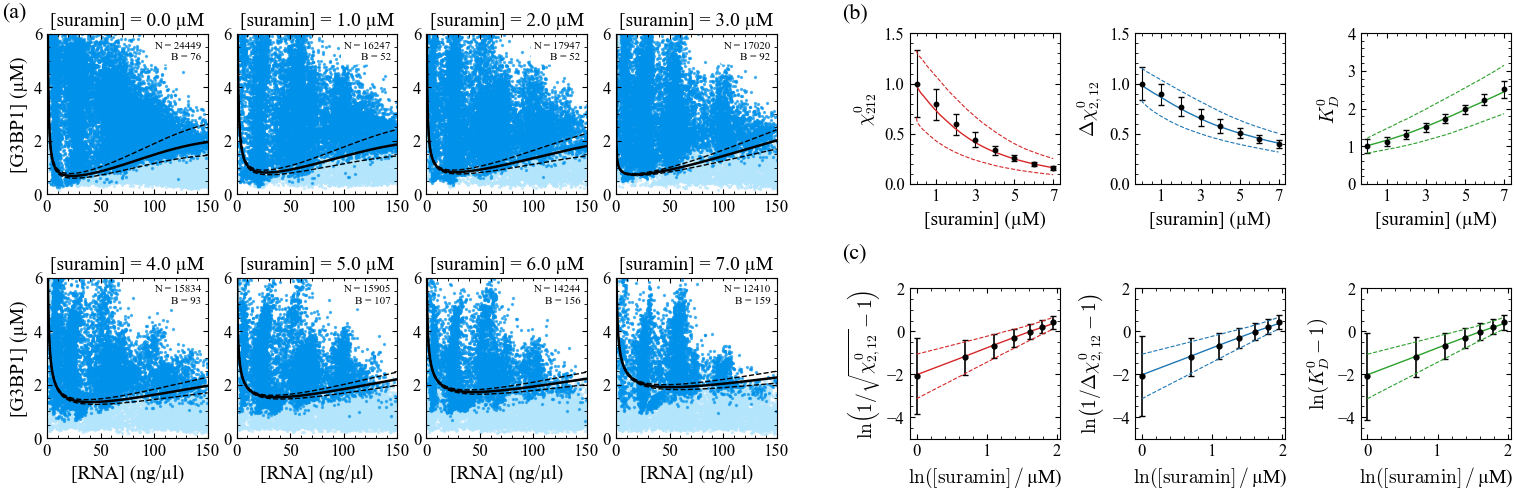

In [13]:
# ==============================================================
# COMPLETE FIGURE (a)+(b)+(c) — UPDATED
#   (a) LEFT: 2×4 grid using your GLOBAL fit curves (fitFun_global)
#   (b) UPPER RIGHT: normalized observables with Hill fits + covariant envelopes
#   (c) LOWER RIGHT: straight-line (log–Hill) linearization with covariant envelopes
# ==============================================================

# ----------------------------
# APS style plot
# ----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "font.size": 10,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.linewidth": 0.8,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    "legend.frameon": False,
    "lines.linewidth": 1.2,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

def apply_prl_ticks(ax):
    ax.minorticks_on()
    ax.tick_params(which="both", direction="in", top=True, right=True)


# ==============================================================
# HARD layout constraints
# ==============================================================
nrows_a, ncols_a = 2, 4
AX_A = 2.10
WSPACE_A = 0.18
HSPACE_A = 0.22
WSPACE_R = 0.50
HSPACE_R = 0.35
MLEFT, MRIGHT, MBOTTOM, MTOP = 0.80, 0.25, 0.70, 0.40
GUTTER = 0.45

gapA_w = WSPACE_A * AX_A
gapA_h = HSPACE_A * AX_A
W_left = ncols_a * AX_A + (ncols_a - 1) * gapA_w
H_left = nrows_a * AX_A + (nrows_a - 1) * gapA_h

gapR_h = HSPACE_R * AX_A
AX_R = (H_left - gapR_h) / 2.0
if AX_R <= 0:
    raise ValueError("H_left too small for chosen HSPACE_R/AX_A. Reduce HSPACE_R or increase AX_A.")
gapR_w = WSPACE_R * AX_R
W_right = 3 * AX_R + 2 * gapR_w

FIG_W = MLEFT + W_left + GUTTER + W_right + MRIGHT
FIG_H = MBOTTOM + H_left + MTOP

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = GridSpec(1, 2, figure=fig, width_ratios=[W_left, W_right], wspace=0.20)





# ==============================================================
# (a) LEFT: 2×4 global-fit phase-boundary grid
# ==============================================================
gs_a = gs[0].subgridspec(nrows_a, ncols_a, wspace=WSPACE_A, hspace=HSPACE_A)
axes_a = np.array([fig.add_subplot(gs_a[r, c]) for r in range(nrows_a) for c in range(ncols_a)])

axes_a[0].text(-0.28, 1.20, "(a)", transform=axes_a[0].transAxes,
               ha="left", va="top", fontsize=16)

names = [f"{val} µM" for val in slab_values]

for i, ax in enumerate(axes_a[:nrows_a * ncols_a]):
    if i >= nslabs:
        ax.remove()
        continue

    section = SECTIONS[i]
    label = section["feature"].values.astype(int)

    dil = section[label == 0]
    den = section[label == 1]

    ax.scatter(dil["RNA"], dil["Protein"], s=2, color='#b3e5fc', alpha=0.6, rasterized=True)
    ax.scatter(den["RNA"], den["Protein"], s=2, color='#0091ea', alpha=0.6, rasterized=True)
    
    X_plot, y_fit, yb_lo, yb_hi = get_fit_and_envelope(
        i, xx, popt, perr, model_global, lower=lower, upper=upper
    )

    ax.plot(xx, y_fit, color="black", lw=1.8)
    ax.plot(xx, yb_hi, color="black", ls="--", lw=1.0)
    ax.plot(xx, yb_lo, color="black", ls="--", lw=1.0)
    
    txt = f"N = {ndata_total[i]}\nB = {bcount_fit[i]}"
    ax.text(0.96, 0.96, txt, transform=ax.transAxes,
            ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=1.0),
            zorder=10)

    ax.set_title("[suramin] = " + names[i])
    ax.set_xlim(0, 150)
    ax.set_ylim(0, 6)

    if i % ncols_a == 0:
        ax.set_ylabel("[G3BP1] (µM)")
    else:
        ax.set_ylabel("")

    if i >= (nrows_a - 1) * ncols_a:
        ax.set_xlabel("[RNA] (ng/µl)")
    else:
        ax.set_xlabel("")

    apply_prl_ticks(ax)
    ax.set_box_aspect(1)
    
    

# ==============================================================
# RIGHT: two rows (b) and (c), each a 1×3 row of square panels
# ==============================================================
gs_r = gs[1].subgridspec(2, 1, hspace=HSPACE_R)



# ==============================================================
# (b) upper right: normalized observables + Hill curves
# ==============================================================
gs_b = gs_r[0].subgridspec(1, 3, wspace=WSPACE_R)
axes_b = [fig.add_subplot(gs_b[0, j]) for j in range(3)]
axes_b[0].text( -0.45, 1.20, "(b)", transform=axes_b[0].transAxes, ha="left", va="top", fontsize=16)

suramin = np.asarray(suramin, dtype=float)
x_fit = np.linspace(0, float(np.max(suramin)), 400)

# χ^0_{2,12} ~ θ^2 
ax = axes_b[0]
ax.errorbar(suramin, chi3n, yerr=chi3n_err, fmt="o", color="k", ms=3.2, lw=0.8, capsize=2)
ax.plot(x_fit, theta2_med, "-",  color="tab:red",   lw=1.0)
ax.plot(x_fit, theta2_lo,  "--", color="tab:red",   lw=0.8)
ax.plot(x_fit, theta2_hi,  "--", color="tab:red",   lw=0.8)
ax.set_xlabel("[suramin] (µM)")
ax.set_ylabel(r"$\chi^{0}_{212}$")
ax.set_xticks([1, 3, 5, 7])
ax.set_ylim(0, 1.5)

# Δχ^0_{2,12} ~ θ 
ax = axes_b[1]
ax.errorbar(suramin, dchin, yerr=dchin_err, fmt="o", color="k", ms=3.2, lw=0.8, capsize=2)
ax.plot(x_fit, theta_med, "-",  color="tab:blue",  lw=1.0)
ax.plot(x_fit, theta_lo,  "--", color="tab:blue",  lw=0.8)
ax.plot(x_fit, theta_hi,  "--", color="tab:blue",  lw=0.8)
ax.set_xlabel("[suramin] (µM)")
ax.set_ylabel(r"$\Delta\chi^{0}_{2,12}$")
ax.set_xticks([1, 3, 5, 7])
ax.set_ylim(0, 1.5)

# K_D^0 ~ 1/θ
ax = axes_b[2]
ax.errorbar(suramin, kdn, yerr=kdn_err, fmt="o", color="k", ms=3.2, lw=0.8, capsize=2)
ax.plot(x_fit, inv_med, "-",  color="tab:green", lw=1.0)
ax.plot(x_fit, inv_lo,  "--", color="tab:green", lw=0.8)
ax.plot(x_fit, inv_hi,  "--", color="tab:green", lw=0.8)
ax.set_xlabel("[suramin] (µM)")
ax.set_ylabel(r"$K_D^0$")
ax.set_xticks([1, 3, 5, 7])
ax.set_ylim(0, 4)

for ax in axes_b:
    apply_prl_ticks(ax)
    ax.set_box_aspect(1)
    
    
    

# ==============================================================
# (c) lower right: straight-line Hill plot with \ln labels
# ==============================================================
gs_c = gs_r[1].subgridspec(1, 3, wspace=WSPACE_R)
axes_c = [fig.add_subplot(gs_c[0, j]) for j in range(3)]
axes_c[0].text(-0.45, 1.30, "(c)", transform=axes_c[0].transAxes, ha="left", va="top", fontsize=16)

x_fit = np.linspace(np.min(X), np.max(X), 400)

# χ^0_{2,12} linearized 
ax = axes_c[0]
ax.errorbar(x_chi_lin, y_chi3_lin, yerr=y_chi3_err_lin, fmt='o', color='k', ms=3.5)
ax.plot(x_fit, yfit_lin, '-',  color='tab:red',   lw=1.0)
ax.plot(x_fit, ylo_lin,  '--', color='tab:red',   lw=0.8)
ax.plot(x_fit, yhi_lin,  '--', color='tab:red',   lw=0.8)
ax.set_xlabel(r"$\ln([\mathrm{suramin}]\,/\,$µM)")
ax.set_ylabel(r"$\ln\!\left(1/\sqrt{\chi^{0}_{2,12}}-1\right)$")
ax.set_ylim(-5, 2)

# Δχ^0_{2,12} linearized 
ax = axes_c[1]
ax.errorbar(x_dchi_lin, y_dchi_lin, yerr=y_dchi_err_lin, fmt='o', color='k', ms=3.5)
ax.plot(x_fit, yfit_lin, '-',  color='tab:blue',  lw=1.0)
ax.plot(x_fit, ylo_lin,  '--', color='tab:blue',  lw=0.8)
ax.plot(x_fit, yhi_lin,  '--', color='tab:blue',  lw=0.8)
ax.set_xlabel(r"$\ln([\mathrm{suramin}]\,/\,$µM)")
ax.set_ylabel(r"$\ln\!\left(1/\Delta\chi^{0}_{2,12}-1\right)$")
ax.set_ylim(-5, 2)

# K_D^0 linearized 
ax = axes_c[2]
ax.errorbar(x_kd_lin, y_kd_lin, yerr=y_kd_err_lin, fmt='o', color='k', ms=3.5)
ax.plot(x_fit, yfit_lin, '-',  color='tab:green', lw=1.0)
ax.plot(x_fit, ylo_lin,  '--', color='tab:green', lw=0.8)
ax.plot(x_fit, yhi_lin,  '--', color='tab:green', lw=0.8)
ax.set_xlabel(r"$\ln([\mathrm{suramin}]\,/\,$µM)")
ax.set_ylabel(r"$\ln\!\left(K^{0}_{D}-1\right)$")
ax.set_ylim(-5, 2)


for ax in axes_c:
    apply_prl_ticks(ax)
    ax.set_box_aspect(1)

    

# ==============================================================
# Export
# ==============================================================
#fig.savefig("Figure_3.pdf")
#fig.savefig("Figure_3.png", dpi=600)
plt.show()
